# $DMO_{n} + Fatigue_{n-1} \rightarrow Fatigue_{n}$

In [33]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import DMOLSTM, ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.core.data_transforms import Transform
from src.train import TrainRegression
from torchmetrics.regression import R2Score

import matplotlib.pyplot as plt

import numpy as np
import torch


In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [35]:
dmo_features = [
    "cadence_30_p90_d",
    "cadence_30_avg_d",
    "ws_30_p90_d",
    "strlen_1030_avg_d",
    "cadence_all_avg_d",
]

In [36]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [37]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/home/gwilym-rutherf

In [38]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [39]:
dmo_data.shape

torch.Size([280, 5, 7, 5])

In [40]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam

config = ModelConfig(
    name="lstm_regression",
    model_type="LSTM",
    input_size=36,
    hidden_size=128,
    num_layers=2,
    output_size=1,
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
)

config.notes = "None"

In [42]:
predicted_values = []
actual_values = []

n_patients, n_visit, n_day, n_features = dmo_data.shape
for patient_index in range(n_patients):
    print(f"X Validation {patient_index}")

    # split data
    train_indexes = [i for i in range(n_patients) if i != patient_index]
    train_data = dmo_data[train_indexes].squeeze(dim=0)
    train_label = dmo_labels[train_indexes]

    test_data = dmo_data[patient_index]
    test_label = dmo_labels[patient_index].unsqueeze(dim=0)

    transform = Transform()

    # fit and transform scaler on training data only, then transform testing
    train_data = transform.fit_transform_dmo_data(train_data)
    test_data = transform.transform_dmo_data(test_data)

    # fit and transform scaler on training labels, then transform testing labels
    train_label = transform.fit_transform_dmo_labels(train_label)
    test_label = transform.transform_dmo_labels(test_label)

    # convert to tensors
    # train_data = torch.from_numpy(train_data)
    train_label = torch.from_numpy(train_label)

    test_data = torch.from_numpy(test_data)
    test_label = torch.from_numpy(test_label)

    

    # format data
    train_data = Transform.format_input_data_lag_label(train_data, train_label)
    test_data = Transform.format_input_data_lag_label(test_data, test_label)

    # raise KeyboardInterrupt

    # Convert to dataloaders
    training_dataloader = Transform.data_to_dataloaders(
        train_data, train_label, batch_size=16
    )
    testing_dataloader = Transform.data_to_dataloaders(
        test_data, test_label, batch_size=16
    )

    # reinstantiate model every loop for x validation
    model = DMOLSTM(config).to(device=device)
    optimiser = config.optimiser(model.parameters(), lr=config.learning_rate)

    trainer = TrainRegression(
        model,
        optimiser,
        config,
        training_dataloader,
        testing_dataloader,
        device,
        verbose=True,
    )

    def label_transform(x):
        if len(x.shape) < 3:
            x = x.unsqueeze(dim=0)
        x = x[:, 4, 0]
        return x

    def pred_transform(x):
        x = x[:, -1, :]
        x = x.flatten()
        return x

    trainer.train_loop(label_transform=label_transform, pred_transform=pred_transform)
    prediction, actual = trainer.test_loop(
        label_transform=label_transform, pred_transform=pred_transform
    )

    predicted_values += prediction
    actual_values += actual


X Validation 0
Testing loss: 0.007730834651738405
X Validation 1
Testing loss: 0.003221245715394616
X Validation 2
Testing loss: 0.0005812096642330289
X Validation 3
Testing loss: 0.004957796540111303
X Validation 4
Testing loss: 0.000844135822262615
X Validation 5
Testing loss: 0.08689036965370178
X Validation 6
Testing loss: 0.0021405527368187904
X Validation 7
Testing loss: 0.038465648889541626
X Validation 8
Testing loss: 0.006649129558354616
X Validation 9
Testing loss: 0.0675293430685997
X Validation 10
Testing loss: 0.02169829234480858
X Validation 11
Testing loss: 0.02365429699420929
X Validation 12
Testing loss: 0.01710989698767662
X Validation 13
Testing loss: 0.03109237365424633
X Validation 14
Testing loss: 0.000637493038084358
X Validation 15
Testing loss: 0.003570136148482561
X Validation 16
Testing loss: 0.009199345484375954
X Validation 17
Testing loss: 0.03175458312034607
X Validation 18
Testing loss: 0.02029503509402275
X Validation 19
Testing loss: 0.0076064951717853

All metrics: {'accuracy': 0.5821428571428572, 'Mean Squared Error': 0.018348345533013344, 'Mean Absolute Error': 0.10603439807891846, 'R^2': 0.6945909857749939}


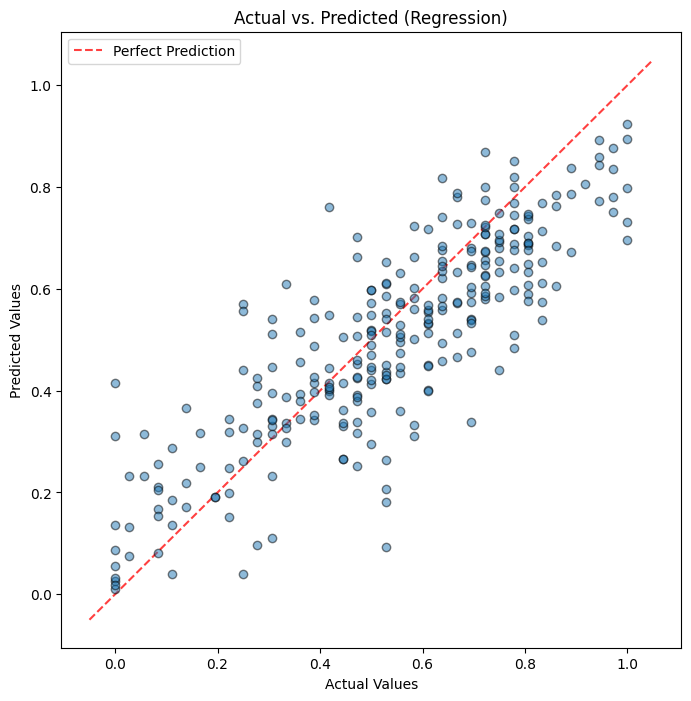

In [43]:
from src.evaluation import Evaluation
import matplotlib.pyplot as plt

actual_values = torch.Tensor(actual_values)
predicted_values = torch.Tensor(predicted_values)

evaluation = Evaluation(predicted_values, actual_values)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
